## Computational Study of Diels-Alder Reaction

The **Diels–Alder (DA) reaction** is a pericyclic [4+2] cycloaddition between a **conjugated diene** and a **dienophile** (typically an alkene or alkyne), resulting in the formation of a six-membered ring. It is one of the most powerful and widely used carbon–carbon bond-forming reactions in organic synthesis, offering high regio- and stereoselectivity under mild conditions. The reaction proceeds via a concerted, symmetry-allowed mechanism governed by the interactions between the **Frontier Molecular Orbitals (FMOs)**—**Highest Occupied Molecular Orbital (HOMO)** and **Lowest Unoccupied Molecular Orbital (LUMO)** of the reactants.

<figure>
  <img src='media/DA_reaction.png' width=350>
  <figcaption style="text-align:left">Figure 1. Diels–Alder reaction, simplest example.<sup>[1]</sup></figcaption>
</figure>

The goal of this project is to integrate computational chemistry tools and molecular orbital theory to rationalize the reactivity and selectivity of DA reactions, reinforcing key concepts in FMO theory, orbital symmetry, and reaction energetics.

In [ ]:
import psi4
import numpy as np
import matplotlib.pyplot as plt
import py3Dmol

In [2]:
psi4.set_memory('2GB')
psi4.set_num_threads(2)
psi4.core.set_output_file("output_DA.dat", False)


  Memory set to   1.863 GiB by Python driver.
  Threads set to 2 by Python driver.


### Part 1: Effect of Dienophile Electron Deficiency on Diels–Alder Reaction Rates

The reactivity of DA reactions is influenced significantly by the electronic nature of the reacting species. In particular, the rate tends to increase when the diene bears **electron-donating groups (EDG)** and the dienophile bears **electron-withdrawing groups (EWG)**. This phenomenon is often explained by **frontier molecular orbital (FMO) theory**: EDGs raise the HOMO energy of the diene, while EWGs lower the LUMO energy of the dienophile. A smaller HOMO–LUMO gap facilitates stronger orbital interactions and thus leads to a lower activation energy and faster reaction rate.  

The LUMO energy of cyano-substituted ethylenes were examined in relation to its correlation with their experimental rate of reaction with cyclopentadiene. Six different dienophiles, ranging from mono- to tetra-cyano substitution, were investigated.  

>Note: Ethene-based synonyms—instead of IUPAC names—were used for simplicity and coherency.

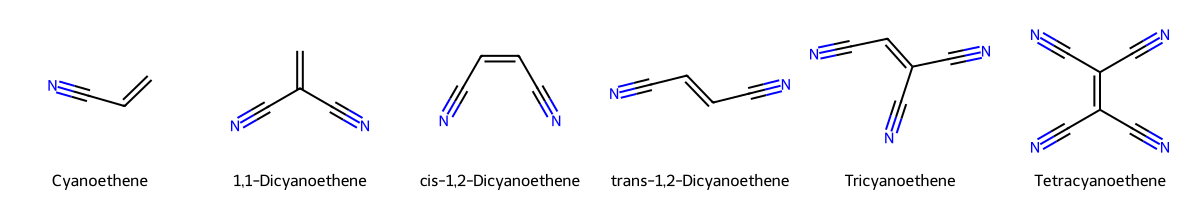

In [2]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsMatrixToGridImage

smiles_ethene = ['N#CC=C', 'N#CC(C#N)=C', 'C(=C\C#N)\C#N', 
                 'C(=C/C#N)\C#N', 'N#CC=C(C#N)C#N', 'N#CC(C#N)=C(C#N)C#N']
mols_ethene = [[Chem.MolFromSmiles(smile) for smile in smiles_ethene]]
names_ethene = [['Cyanoethene', '1,1-Dicyanoethene', 'cis-1,2-Dicyanoethene', 
                 'trans-1,2-Dicyanoethene', 'Tricyanoethene', 'Tetracyanoethene']]
MolsMatrixToGridImage(molsMatrix=mols_ethene, legendsMatrix=names_ethene)

The geometries of these cyano-substituted ethenes were constructed programmatically using Z-matrix templates.

In [ ]:
backbone = """
symmetry c1
0 1
C
C 1 1.34
sub1 2 120
sub2 2 120 3 180
sub3 1 120 3 0
sub4 1 120 3 180
sub5
sub6
sub7
sub8
"""

H12 = 'H 1 1.08'
H34 = 'H 2 1.08'
C12 = 'C 1 1.54'
C34 = 'C 2 1.54'
N1 = 'N 3 1.14 1 180 2 0'
N2 = 'N 4 1.14 1 180 2 0'
N3 = 'N 5 1.14 2 180 1 0'
N4 = 'N 6 1.14 2 180 1 0'

def replace_sub(sub1, sub2, sub3, sub4, sub5, sub6, sub7, sub8):
    replacements = {'sub1': sub1, 'sub2': sub2, 'sub3': sub3, 'sub4': sub4,
                    'sub5': sub5, 'sub6': sub6, 'sub7': sub7, 'sub8': sub8,}
    molecule = backbone
    for old, new in replacements.items():
        molecule = molecule.replace(old, new)
    return molecule

mono = replace_sub(C12, H12, H34, H34, N1, '', '', '').strip()  # Cyanoethene
di = replace_sub(C12, C12, H34, H34, N1, N2, '', '').strip()  # 1,1-Dicyanoethylene
cis_di = replace_sub(C12, H12, C34, H34, N1, N3, '', '').strip()  # cis-1,2-Dicyanoethylene
trans_di = replace_sub(C12, H12, H34, C34, N1, N4, '', '').strip()  # trans-1,2-Dicyanoethylene
tri = replace_sub(C12, C12, C34, H34, N1, N2, N3, '').strip()  # Tricyanoethylene
tetra = replace_sub(C12, C12, C34, C34, N1, N2, N3, N4).strip()  # Tetracyanoethylene

Geometry optimizations were performed at the **HF/6-31G(d)** level using `Psi4`, and the LUMO energy of each dienophile was extracted from the wavefunction object. Psi4 stores the molecular orbital energies separately for alpha and beta electrons. For closed-shell systems such as those examined here (where all orbitals are doubly occupied), the number of alpha electrons is equal to the number of occupied orbitals. The `wfn.nalpha()` function returns this number. Thus, the $n$<sup>th</sup> orbital (where $n$ = `nalpha()`) corresponds to the HOMO of the molecule. However, since NumPy arrays are indexed starting from zero in Python, the index n returns the ($n+1$)<sup>th</sup> orbital, i.e. the LUMO.

In [ ]:
cyanoethene = [mono, di, cis_di, trans_di, tri, tetra]
LUMO_cyanoethene = []

for mol in cyanoethene:
    psi4.core.clean()
    geom = psi4.geometry(mol)
    E, wfn = psi4.optimize('HF/6-31G(d)', molecule = geom, return_wfn=True)

    LUMO = wfn.epsilon_a_subset("AO", "ALL").np[wfn.nalpha()]
    LUMO_cyanoethene.append(LUMO)

    psi4.core.clean()

To visualize the effect of LUMO energy on the DA reaction rate, a scatter plot was generated using the computed LUMO energies of substituted ethylenes and the logarithm of their experimental relative reaction rates.<sup>[2]</sup>

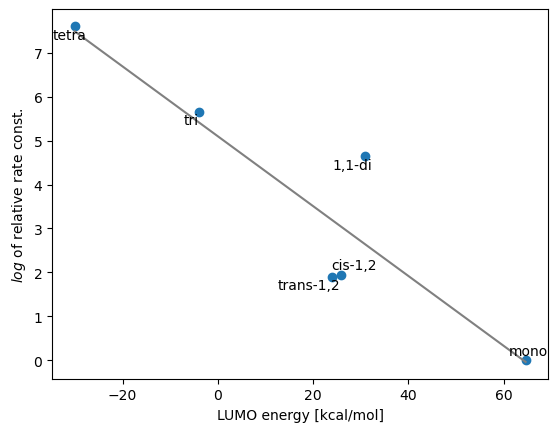

In [23]:
from adjustText import adjust_text
conv = psi4.constants.hartree2kcalmol

rate = [0, 4.64, 1.94, 1.89, 5.66, 7.61]
label = ['mono', '1,1-di', 'cis-1,2', 'trans-1,2', 'tri', 'tetra']

x, y = [i*conv for i in LUMO_cyanoethene], rate
plt.scatter(x, y)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='gray', linestyle='-')

texts = [plt.text(x[i], y[i], label[i], ha='center', va='center') for i in range(len(x))]
adjust_text(texts)
plt.xlabel('LUMO energy [kcal/mol]', fontsize=10)
plt.ylabel('$log$ of relative rate const.', fontsize=10)

plt.show()

A linear fit was applied using `np.polyfit()`, which computes the least-squares polynomial fit. The resulting line suggests a negative linear correlation: as the LUMO energy decreases, the reaction rate increases. This trend supports the FMO theory, which states that a lower LUMO energy in the dienophile facilitates a smaller HOMO–LUMO gap, enhancing orbital overlap with the diene and accelerating the reaction.

While the overall correlation is reasonable, dicyanoethenes—particularly 1,1-dicyanoethene—exhibit noticeable deviation from the fitted line. In 1,1-dicyanoethene, the two cyano groups are attached to the same carbon, possibly leading to electronic repulsion or reduced conjugation efficiency compared to 1,2-substitution patterns. Despite these deviations, the general linear trend remains valid and supports the hypothesis that lowering the dienophile’s LUMO energy increases the DA reactivity.

### Part 2: Potential Energy Surface Scan of Diene Rotation Around Central Bond

Dienes can adopt two conformations around the central C–C bond: **s-cis** and **s-trans**. These terms refer to the spatial arrangement of the $\pi$ bonds: in the *s-cis* conformation, the two $\pi$ bonds lie on the same side of the single bond (dihedral angle ≈ 0–60°), whereas in *s-trans*, they lie on opposite sides (dihedral angle ≈ 180°). 

<figure>
  <img src='media/DA_cis_trans.png' width=350>
  <figcaption style="text-align:left">Figure 2. s-cis and s-trans conformations.<sup>[3]</sup></figcaption>
</figure>

Although the *s-trans* conformation is generally more stable due to reduced steric strain, the *s-cis* conformation is required for participation in a DA reaction. In cyclic systems such as cyclopentadiene, the *s-cis* geometry is inherently fixed and no conformational rotation is needed.

To analyze the energetics of this rotation, a **Potential Energy Surface (PES) scan** was performed for several dienes by varying the central dihedral angle from 0° to 180° in 10° intervals. Due to the computational cost, these scans were carried out using a smaller basis set, **3-21G**. 

In [12]:
PES_dict, dihedral_dict = {}, {}
dihedrals = np.linspace(0, 180, 19)  # in 10° interval
psi4.core.clean_options()

def PES_dihedral(molecule: str): 
    with open(f'molecule/{molecule}.txt', 'r') as f:
        mol = f.read()

    geom = psi4.geometry(mol)

    psi4.set_options({'basis': '3-21G',
                      'intrafrag_step_limit': 0.1,
                      'frozen_dihedral': (' 1 2 3 4 ')})

    PES_dict[molecule] = []

    for phi in dihedrals:
        geom.D = phi
        E = psi4.optimize('HF')
        PES_dict[molecule].append(E)
    
    psi4.core.clean()

1.3-Butadiene and 6 different substituted butadienes were studied.   
>Note: Butadiene-based synonyms—instead of IUPAC names—were used for simplicity and coherency.

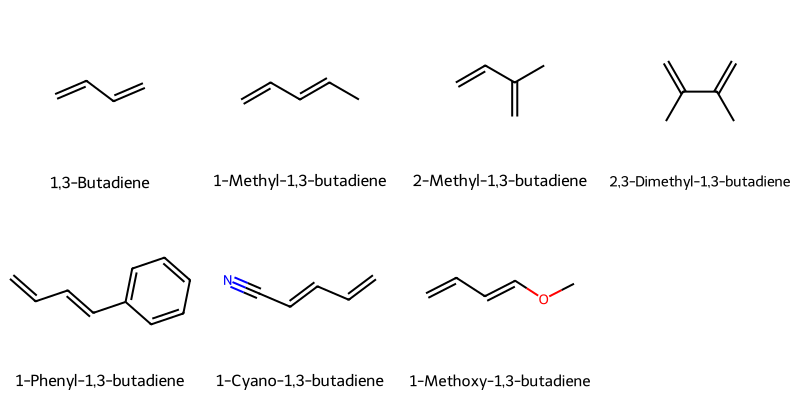

In [3]:
smiles_diene = [['C=CC=C', 'C=CC=CC', 'C=CC(=C)C', 'C=C(C(=C)C)C'], 
                ['C=CC=CC=1C=CC=CC1', 'N#CC=CC=C', 'O(C=CC=C)C']]
mols_diene = [[Chem.MolFromSmiles(smile) for smile in row] for row in smiles_diene]
names_diene = [['1,3-Butadiene', '1-Methyl-1,3-butadiene', 
                '2-Methyl-1,3-butadiene', '2,3-Dimethyl-1,3-butadiene'],
               ['1-Phenyl-1,3-butadiene', '1-Cyano-1,3-butadiene', '1-Methoxy-1,3-butadiene']]
MolsMatrixToGridImage(molsMatrix=mols_diene, legendsMatrix=names_diene)

In [ ]:
substituents = ['unsubst', 'methyl', '2-methyl', 'dimethyl', 'phenyl', 'cyano', 'methoxy']
for sub in substituents:
    PES_dihedral(f'diene_{sub}')
    print(f'diene_{sub}: complete')

The computed energies were normalized for each molecule by setting the minimum energy to zero and then plotted against the dihedral angle in the following PES plot.

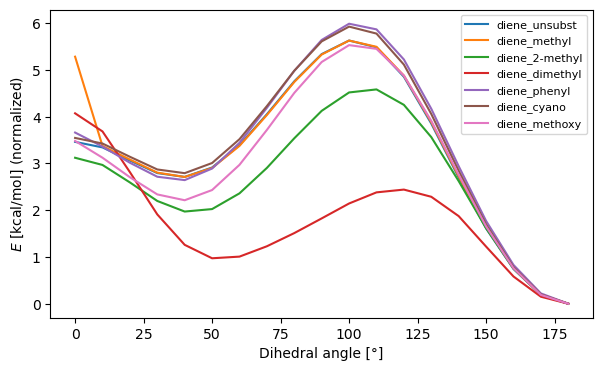

In [26]:
plt.figure(figsize=(7, 4))

for key, val in PES_dict.items():
    converted = [i*conv for i in val]
    normalized = [i-min(converted) for i in converted]
    plt.plot(dihedrals, normalized, label=key)

plt.xlabel('Dihedral angle [°]', fontsize=10)
plt.ylabel('$E$ [kcal/mol] (normalized)', fontsize=10)

plt.legend(fontsize=8)
plt.show()

The PES plot reveals the following general trends:

- The global minimum for all dienes lies at approximately 180°, corresponding to the stable s-trans conformation.

- A global maximum is observed around 100°, and a local minimum in the s-cis region occurs at approximately 40°.

- For dienes with substituents on the secondary carbon (e.g., 2-methyl and 2,3-dimethyl), both the local minima and maxima are shifted to slightly larger dihedral angles. This shift is likely due to steric interactions that push the substituents away from the conjugated π system, thereby altering the optimal geometry.

- Additionally, these secondary-substituted dienes exhibit lower rotational barriers, possibly because their bulky groups already interact sterically with other parts of the molecule, regardless of the dihedral angle. Electronic stabilization (e.g., hyperconjugation) may also contribute.

- The 2,3-dimethylbutadiene shows the most notable deviation: the energy difference between the s-cis and s-trans conformers is significantly smaller, suggesting increased conformational flexibility.

- Dienes with substituents on the primary carbon (e.g., methyl, phenyl, cyano, methoxy) and the unsubstituted diene all exhibit similar PES profiles. This similarity is attributed to the greater distance between the primary substituent and the rotational axis, resulting in minimal steric influence.

- Among these, the phenyl-substituted diene shows the highest rotational barrier, likely due to its bulky structure.

> Note: The absolute values and fine features of the PES may not be fully accurate due to the use of a minimal basis set (3-21G), which limits the description of electron correlation and polarization effects.

To quantify the barrier for *s-trans* → *s-cis* interconversion, **transition state (TS)** and **minimum** geometries were optimized at dihedral angles corresponding to the PES maximum and minimum, respectively. These optimizations were performed at the **HF/6-31G(d)** level of theory. The **activation energy ($E_a$)** was then calculated as the energy difference between these points.

In [16]:
Emax_dict, Emin_dict = {}, {}
psi4.core.clean()
psi4.core.clean_options()

for key in PES_dict.keys():
    with open(f'molecule/{key}.txt', 'r') as f:
        mol = f.read()

    PES = PES_dict[key]
    dihedral_max = PES.index( max(PES) ) * 10  # bcs dihedral in 10° interval
    dihedral_min = PES.index( min(PES) ) * 10
    
    # Dihedral angle at the energy maximum (TS)
    geom = psi4.geometry(mol)
    geom.D = dihedral_max
    psi4.set_options({'opt_type': 'ts'})
    Emax = psi4.optimize('HF/6-31G(d)')
    Emax_dict[key] = Emax
    psi4.core.clean()
    psi4.core.clean_options()

    # Dihedral angle at the energy manimum (s-trans)
    geom = psi4.geometry(mol)
    geom.D = dihedral_min
    psi4.set_options({'opt_type': 'min'})
    Emin = psi4.optimize('HF/6-31G(d)')
    Emin_dict[key] = Emin
    psi4.core.clean()

	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.15.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.01e-05

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.38e-05

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.96e-07

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.18e-08



Optimizer: Optimization complete!
Optimizer: Optimization complete!


	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.15.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.52e-06

	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.25.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.25e-06

	Change in internal coordinate of 5.06e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 6.
	Change in internal coordinate of 7.26e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 8.
	Change in internal coordinate of 8.10e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 7.
	Change in internal coordinate of 8.96e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 6.
	Change in internal coordinate of 8.58e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 5.
	Change in internal coordinate of 6.93e-01 exce

Optimizer: Optimization complete!
Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.04e-04

	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.15.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.57e-05

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.90e-06

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 9.51e-07

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 6.78e-08



...

Optimizer: Optimization complete!
Optimizer: Optimization complete!


	Unable to completely converge to displaced geometry.
	RMS(dx):  1.786e-06 	Max(dx):  4.749e-06 	RMS(dq):  1.982e-04
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.98e-04

	Change in internal coordinate of 5.11e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 5.59e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 4.
	Change in internal coordinate of 9.23e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 9.23e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.25.
	Change in internal coordinate of 5.63e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 4.
	Change in internal coordinate of 9.28e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate o

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.02e-09



Optimizer: Optimization complete!


In [27]:
for key in PES_dict.keys():
    Emin, Emax = Emin_dict[key]*conv, Emax_dict[key]*conv
    print(f'{key}: Ea = {Emax:.2f} kcal/mol - ({Emin:.2f} kcal/mol) = {Emax-Emin:.2f} kcal/mol')

diene_unsubst: Ea = -97207.38 kcal/mol - (-97213.45 kcal/mol) = 6.07 kcal/mol
diene_methyl: Ea = -121704.98 kcal/mol - (-121709.12 kcal/mol) = 4.14 kcal/mol
diene_2-methyl: Ea = -121704.65 kcal/mol - (-121709.88 kcal/mol) = 5.23 kcal/mol
diene_dimethyl: Ea = -146200.21 kcal/mol - (-146204.89 kcal/mol) = 4.68 kcal/mol
diene_phenyl: Ea = -241254.14 kcal/mol - (-241260.65 kcal/mol) = 6.51 kcal/mol
diene_cyano: Ea = -154773.21 kcal/mol - (-154779.68 kcal/mol) = 6.47 kcal/mol
diene_methoxy: Ea = -168668.11 kcal/mol - (-168674.12 kcal/mol) = 6.01 kcal/mol


These results indicate that the activation barrier is relatively low (~4–6.5 kcal/mol), suggesting that rotation into the *s-cis* conformation is readily accessible at room temperature. For comparison, typical activation energies for chemical reactions range from 10–30 kcal/mol, depending on the process.<sup>[4]</sup> Thus, the conformational interconversion is not rate-limiting in most DA reactions.

### Normal vs. Inverse Electron Demand in the DA Reaction

DA reactions typically proceed between an **electron-rich diene** and an **electron-poor dienophile**, a mode known as **normal electron demand**. In such cases, the primary orbital interaction occurs between the **HOMO of the diene** and the **LUMO of the dienophile**. However, when this electronic arrangement is reversed—such as using an **electron-poor diene** and an **electron-rich dienophile**—the reaction proceeds via **inverse electron demand**, involving interaction between the **HOMO of the dienophile** and the **LUMO of the diene**.

<figure>
  <img src='media/DA_FMO.png' width=500>
  <figcaption style="text-align:left">Figure 3. FMO analysis of normal and inverse electron demand in the DA reaction.<sup>[1]</sup></figcaption>
</figure>

The ability to tune DA reactions using substituents was demonstrated using **methoxy** (an electron-donating group, EDG) and **cyano** (an electron-withdrawing group, EWG) substituents. The following two pairs were studied:
- **Normal electron demand**: 
    - Diene (D1): 1-Methoxy-1,3-butadiene (electron-rich)
    - Dienophile (DP1): Cyanoethene (electron-poor)
- **Inverse electron demand**:
    - Diene (D2): 1-Cyano-1,3-butadiene (electron-poor)
    - Dienophile (DP2): Methoxyethene (electron-rich)

In [18]:
wfn_dict, HOMO_dict, LUMO_dict = {}, {}, {}

for key in PES_dict.keys():
    with open(f'molecule/{key}.txt', 'r') as f:
        mol = f.read()

    # Find the minimum within s-cis dihedral range (0-90°)
    PES_cis = PES_dict[key][:10]
    dihedral_cis = PES_cis.index( min(PES_cis) ) * 10 

    geom = psi4.geometry(mol)
    geom.D = dihedral_cis

    E, wfn = psi4.optimize('HF/6-31G(d)', return_wfn=True)
    wfn_dict[key] = wfn

    HOMO_dict[key] = wfn.epsilon_a_subset("AO", "ALL").np[wfn.nalpha()-1]
    LUMO_dict[key] = wfn.epsilon_a_subset("AO", "ALL").np[wfn.nalpha()]

    psi4.core.clean()

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.31e-09



Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.26e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.25.
	Change in internal coordinate of 7.49e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 9.
	Change in internal coordinate of 8.04e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 8.
	Change in internal coordinate of 8.42e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 7.
	Change in internal coordinate of 8.50e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 6.
	Change in internal coordinate of 7.16e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 5.
	Change in internal coordinate of 7.62e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 4.
	Change in internal coordinate of 7.87e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.34e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.17e-08



...

Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.45e-04

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 4.07e-08



Optimizer: Optimization complete!


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 6.60e-05

	Energy has increased in a minimization.
	Energy ratio indicates iffy step.
	Intrafrag trust radius decreased to   0.25.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 7.24e-09

	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 1.64e-09



Optimizer: Optimization complete!


In [19]:
def calc_HOMO_LUMO(molecule: str): 
    with open(f'molecule/{molecule}.txt', 'r') as f:
        mol = f.read()

    geom = psi4.geometry(mol)

    psi4.core.clean()
    E, wfn = psi4.optimize('HF/6-31G(d)', molecule = geom, return_wfn=True)
    wfn_dict[molecule] = wfn
    
    HOMO_dict[molecule] = wfn.epsilon_a_subset("AO", "ALL").np[wfn.nalpha()-1]
    LUMO_dict[molecule] = wfn.epsilon_a_subset("AO", "ALL").np[wfn.nalpha()]

    psi4.core.clean()

calc_HOMO_LUMO('ethene_cyano')
calc_HOMO_LUMO('ethene_methoxy')

Optimizer: Optimization complete!
Optimizer: Optimization complete!


In [ ]:
# Diene 1 (D1): 1-Methoxy-1,3-butadiene
# Dienophile 1 (DP1): Cyanoethene
HD_LDP1 = abs(HOMO_dict['diene_methoxy'] - LUMO_dict['ethene_cyano'])*conv
HDP_LD1 = abs(HOMO_dict['ethene_cyano'] - LUMO_dict['diene_methoxy'])*conv
print(f'HOMO(D1)-LUMO(DP1) gap: {HD_LDP1:.2f} kcal/mol')
print(f'HOMO(DP1)-LUMO(D1) gap: {HDP_LD1:.2f} kcal/mol')

HOMO(D1)-LUMO(DP1) gap: 257.79 kcal/mol
HOMO(DP1)-LUMO(D1) gap: 344.67 kcal/mol


As expected, the smaller gap for HOMO<sub>diene</sub>–LUMO<sub>dienophile</sub> confirms a normal electron demand mechanism.

In [ ]:
# Diene 2 (D2): 1-Cyano-1,3-butadiene
# Dienophile 2 (DP2): Methoxyethene
HD_LDP2 = abs(HOMO_dict['diene_cyano'] - LUMO_dict['ethene_methoxy'])*conv
HDP_LD2 = abs(HOMO_dict['ethene_methoxy'] - LUMO_dict['diene_cyano'])*conv
print(f'HOMO(D2)-LUMO(DP2) gap: {HD_LDP2:.2f} kcal/mol')
print(f'HOMO(DP2)-LUMO(D2) gap: {HDP_LD2:.2f} kcal/mol')

HOMO(D2)-LUMO(DP2) gap: 350.05 kcal/mol
HOMO(DP2)-LUMO(D2) gap: 259.42 kcal/mol


In this case, the smaller HOMO<sub>dienophile</sub>–LUMO<sub>diene</sub> gap suggests a inverse electron demand mechanism.

These results demonstrate how strategic placement of electron-donating or electron-withdrawing substituents can reverse the orbital interaction driving the DA reaction. As established in Part 1, the HOMO–LUMO energy gap plays a significant role in determining the reaction rate, meaning proper substituent selection can enhance reactivity. The concept of reverse electron demand expands the versatility of the DA reaction, enabling the synthesis of a broader range of compounds.

### Part 4: Visualization of the Frontier Molecular Orbitals

The new C–C $\sigma$-bonds in a DA reaction are formed through the **constructive overlap** of $\pi$ molecular orbitals at the terminal carbon atoms (C1 and C4) of the diene and C1 and C2 of the dienophile. For these bonds to form effectively, the interacting orbitals must have **lobes of the same phase**, enabling constructive interference. By analyzing the shapes of the frontier molecular orbitals in terms of the **node count** and **phase symmetry**, it will be examined whether the HOMO and LUMO of the diene and dienophile can have the constructive overlap, leading to formation of new C-C bonds. 

The frontier molecular orbitals (HOMO and LUMO) of the diene and dienophile were visualized using `py3Dmol` to analyze the bonding interactions in both normal and reverse electron DA reactions. 

In [34]:
def generate_view(homo, lumo, mol):
    view = py3Dmol.view(width=800, height=300, viewergrid=(1,2))

    # HOMO
    view.addVolumetricData(homo, 'cube',
        {'isoval': 0.03, 'smoothness': 5, 'opacity': 0.8, 'color': 'blue'}, viewer=(0,0))
    view.addVolumetricData(homo, 'cube',
        {'isoval': -0.03, 'smoothness': 5, 'opacity': 0.8, 'color': 'orange'}, viewer=(0,0))

    # LUMO
    view.addVolumetricData(lumo, 'cube',
        {'isoval': 0.03, 'smoothness': 5, 'opacity': 0.8, 'color': 'blue'}, viewer=(0,1))
    view.addVolumetricData(lumo, 'cube',
        {'isoval': -0.03, 'smoothness': 5, 'opacity': 0.8, 'color': 'orange'}, viewer=(0,1))

    view.addModel(mol, 'xyz')
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
    view.setBackgroundColor('#9880d1')
    view.zoomTo()
    view.show()

Each molecule was processed using Psi4’s `cubeprop()` function to extract HOMO and LUMO volumetric data.

In [35]:
from pathlib import Path
import glob

def visualize_orbitals(molecule: str):
    filepath = Path(f'orbital/{molecule}')  
    filepath.mkdir(parents=True, exist_ok=True)
    psi4.set_options({'cubeprop_tasks': ['frontier_orbitals'],
                      'cubeprop_filepath': str(filepath) + '/'})

    psi4.cubeprop(wfn_dict[molecule])
    psi4.core.clean_options()

    with open(glob.glob(f'orbital/{molecule}/*.xyz')[0], 'r') as f:
        geom = f.read()
    with open(glob.glob(f'orbital/{molecule}/*HOMO.cube')[0], 'r') as f:
        homo_voldata = f.read()
    with open(glob.glob(f'orbital/{molecule}/*LUMO.cube')[0], 'r') as f:
        lumo_voldata = f.read()    

    generate_view(homo_voldata, lumo_voldata, geom)

First, the FMOs of the normal electron demand pair were visualized.
- 1-Methoxy-1,3-butadiene (D1) 
- Cyanoethene (DP1)

>Note: The original 3D orbital visualizations rendered using `py3Dmol` have been replaced with static image captures to reduce the notebook file size and comply with GitHub’s file size limit. The interactive visualizations can still be rendered by downloading and running the notebook locally.

In [36]:
visualize_orbitals('diene_methoxy')

<img src='media/FMO_diene_methoxy.png' width=800>

In [37]:
visualize_orbitals('ethene_cyano')

<img src='media/FMO_ethene_cyano.png' width=800>

The HOMO and LUMO of both reactants were visualized and analyzed for orbital symmetry and phase relationships.   

>Note: Only the carbon backbone of each molecule was considered in the analysis, as only the π-orbitals on the main skeleton and not the substituents are directly involved in the reaction.

- **HOMO of the diene** has one node across the conjugated system, resulting in opposite-phase lobes on C1 and C4.
- **LUMO of the dienophile** also has one node, leading to opposite-phase lobes on the reactive carbons.

    -> When these orbitals interact, the opposite phases on both sides align, allowing constructive   overlap and bond formation.

- **LUMO of the diene** has two nodes, placing same-phase lobes on C1 and C4.
- **HOMO of the dienophile** has zero nodes, also giving same-phase lobes on the reactive carbons.

    -> This combination is also symmetry-allowed and permits constructive overlap.

Although both HOMO–LUMO combinations are symmetry-allowed, the reaction proceeds through the HOMO of the diene and the LUMO of the dienophile, because this pair exhibits a smaller energy gap as seen in Part 3, leading to a more favorable interaction and reaction kinetics.

Next, the FMOs of the inverse electron demand pair were visualized.
- 1-Cyano-1,3-butadiene (D2)
- Methoxyethene (DP2)

In [ ]:
visualize_orbitals('diene_cyano')

<img src='media/FMO_diene_cyano.png' width=800>

In [ ]:
visualize_orbitals('ethene_methoxy')

<img src='media/FMO_ethene_methoxy.png' width=800>

In the inverse electron demand case, the FMOs exhibit the same phase symmetry and nodal patterns as in the normal demand scenario. Both orbital interactions (HOMO<sub>diene</sub>–LUMO<sub>dienophile</sub> and HOMO<sub>dienophile</sub>–LUMO<sub>diene</sub>) possess the requisite symmetry for constructive overlap at the terminal carbon atoms involved in bond formation. However, due to the significantly smaller HOMO–LUMO energy gap for the HOMO<sub>dienophile</sub>–LUMO<sub>diene</sub> interaction, this pathway is more energetically favorable and thus governs the cycloaddition reactivity under reverse electron demand conditions.

### References

[1] Diels–Alder Reaction. Wikipedia. https://en.wikipedia.org/wiki/Diels%E2%80%93Alder_reaction (accessed May 28, 2025).

[2] Domingo, L. R.; Ríos-Gutiérrez, M.; Pérez, P. A Molecular Electron Density Theory Study of the Diels–Alder Reaction Using Ethylene as Dienophile. Phys. Chem. Chem. Phys. 2013, 15, 7311. https://doi.org/10.1039/C3CP44197K

[3] Butadiene s-cis and s-trans conformations. Wikimedia Commons. https://commons.wikimedia.org/wiki/File:Butadiene_s-cis_and_s-trans_conformations.svg (accessed May 28, 2025)

[4] Atkins, P.; de Paula, J. Physical Chemistry, 10th ed.; Oxford University Press: Oxford, 2014; p 890.